# 4. Modelos de Regresión (ML)

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook entrena los **8 modelos de regresión obligatorios** sobre el target `target_vol_7` y compara su desempeño con los benchmarks econométricos del notebook 03.

| Modelo | Familia | Justificación |
|---|---|---|
| **KNN Regressor** | Basado en distancia | Cap. 2 |
| **Ridge** | Lineal regularizado L2 | Cap. 3 — referencia metodológica |
| **Lasso** | Lineal regularizado L1 | Cap. 3 — selección de features |
| **ElasticNet** | Lineal L1+L2 | Generaliza Ridge y Lasso |
| **Decision Tree** | Árbol no-paramétrico | Cap. 5 — bloque base de RF/XGB |
| **Random Forest** | Bagging de árboles | Cap. 5 — ensamble por varianza |
| **SVR** | Kernel rbf | Cap. 6 — modelo no-lineal |
| **XGBoost** | Boosting de árboles | Cap. 5 — ensamble por sesgo |

**Política metodológica:**
- Validación cruzada interna: `TimeSeriesSplit(n_splits=5)` sobre train+val.
- Evaluación final sobre **test holdout** (15% más reciente).
- Todos los modelos viven dentro de un `Pipeline` para garantizar ausencia de leakage.
- Los hiperparámetros aquí son los **defaults razonables**; la optimización formal se deja al notebook 07.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports

In [2]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)

from src.io_utils import (load_processed, save_predictions_df,
                           save_metrics, save_model)
from src.pipelines import get_regression_pipelines
from src.splits import make_tscv
from src.viz import set_style, color_for
from src.config import DATA_PROCESSED

set_style()

## 2. Cargar datos

In [3]:
train = load_processed("train_reg")
val = load_processed("val_reg")
test = load_processed("test_reg")

# Concatenar train+val para el ajuste final (la CV interna se hace dentro)
trainval = pd.concat([train, val]).reset_index(drop=True)

# Cargar lista de features
with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

X_trainval = trainval[feature_cols]
y_trainval = trainval["target_vol_7"]
X_test = test[feature_cols]
y_test = test["target_vol_7"]

print(f"Train+Val: {X_trainval.shape}")
print(f"Test:      {X_test.shape}")
print(f"Features:  {len(feature_cols)}")

Train+Val: (5920, 59)
Test:      (1045, 59)
Features:  59


## 3. Validación cruzada temporal con TimeSeriesSplit

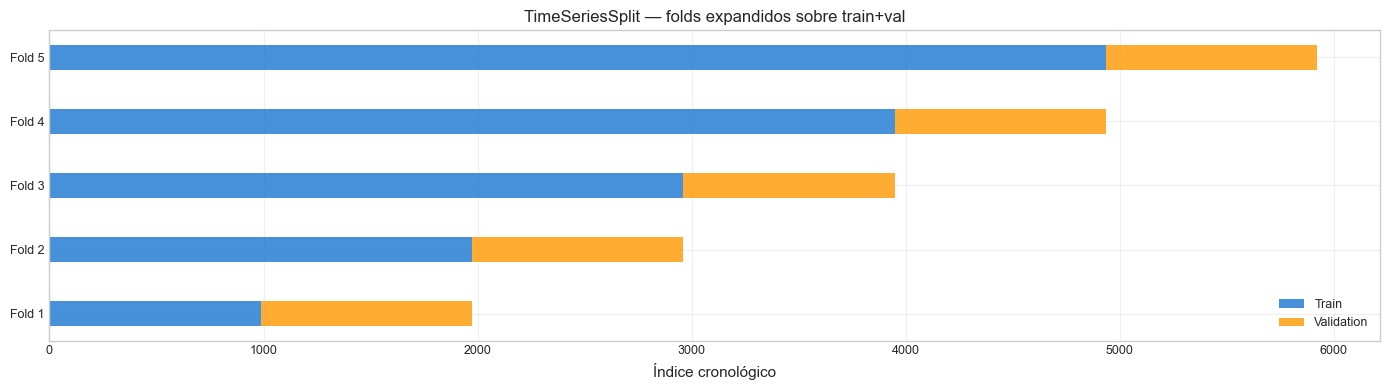


Distribución de folds:
  Fold 1: train=  990 | val= 986 | val_start=1994-02-08
  Fold 2: train= 1976 | val= 986 | val_start=1998-01-05
  Fold 3: train= 2962 | val= 986 | val_start=2001-12-07
  Fold 4: train= 3948 | val= 986 | val_start=2005-11-07
  Fold 5: train= 4934 | val= 986 | val_start=2009-10-08


In [4]:
tscv = make_tscv(n_splits=5)

# Visualizar los folds
fig, ax = plt.subplots(figsize=(14, 4))
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_trainval)):
    ax.barh(i, len(tr_idx), left=0, height=0.4, color="#1976D2",
            alpha=0.8, label="Train" if i == 0 else "")
    ax.barh(i, len(val_idx), left=len(tr_idx), height=0.4, color="#FF9800",
            alpha=0.8, label="Validation" if i == 0 else "")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Índice cronológico")
ax.set_title("TimeSeriesSplit — folds expandidos sobre train+val")
ax.legend()
plt.tight_layout()
plt.show()

print("\nDistribución de folds:")
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_trainval)):
    print(f"  Fold {i+1}: train={len(tr_idx):>5} | val={len(val_idx):>4} "
          f"| val_start={trainval.iloc[val_idx[0]]['date'].date()}")

---

> **📊 Interpretación:** El esquema `TimeSeriesSplit` con folds expandidos respeta estrictamente la temporalidad: cada fold valida sobre un período **posterior** al de entrenamiento, simulando la situación realista de un modelo en producción que solo conoce el pasado. Los folds tempranos (Fold 1) tienen poco entrenamiento pero validan sobre períodos turbulentos; los folds tardíos tienen más entrenamiento y validan sobre períodos más recientes. Promediar las 5 métricas reduce el riesgo de sobreajuste a un período particular.


## 4. Definir modelos y entrenar

In [5]:
models = get_regression_pipelines()
print("Modelos a evaluar:")
for name in models:
    print(f"  - {name}")

Modelos a evaluar:
  - KNN
  - Ridge
  - Lasso
  - ElasticNet
  - Decision Tree
  - Random Forest
  - SVR
  - XGBoost


In [6]:
results_cv = []
results_test = []
predictions = {}
trained_models = {}

for name, pipe in models.items():
    print(f"\nEntrenando {name}...")

    # CV temporal con RMSE
    t0 = time.time()
    rmse_scores = -cross_val_score(pipe, X_trainval, y_trainval,
                                     cv=tscv,
                                     scoring="neg_root_mean_squared_error",
                                     n_jobs=-1)
    mae_scores = -cross_val_score(pipe, X_trainval, y_trainval,
                                    cv=tscv,
                                    scoring="neg_mean_absolute_error",
                                    n_jobs=-1)
    r2_scores = cross_val_score(pipe, X_trainval, y_trainval,
                                 cv=tscv,
                                 scoring="r2",
                                 n_jobs=-1)
    t_cv = time.time() - t0

    # Ajuste final sobre train+val y predicción en test
    t0 = time.time()
    pipe.fit(X_trainval, y_trainval)
    t_fit = time.time() - t0
    yp_test = pipe.predict(X_test)
    yp_train = pipe.predict(X_trainval)

    # Guardar
    predictions[name] = yp_test
    trained_models[name] = pipe

    results_cv.append({
        "Modelo": name,
        "RMSE_CV_mean": rmse_scores.mean(),
        "RMSE_CV_std":  rmse_scores.std(),
        "MAE_CV":       mae_scores.mean(),
        "R2_CV":        r2_scores.mean(),
        "Tiempo_CV":    round(t_cv, 2),
    })
    results_test.append({
        "Modelo": name,
        "RMSE_test": np.sqrt(mean_squared_error(y_test, yp_test)),
        "MAE_test":  mean_absolute_error(y_test, yp_test),
        "R2_test":   r2_score(y_test, yp_test),
        "R2_train":  r2_score(y_trainval, yp_train),
        "Tiempo_fit": round(t_fit, 2),
    })
    print(f"  CV RMSE: {rmse_scores.mean():.6f} ± {rmse_scores.std():.6f}")
    print(f"  Test R²: {r2_score(y_test, yp_test):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, yp_test)):.6f}")


Entrenando KNN...


C:\Users\Mateo\2026\UNINORTE\envs\intc-volforecast\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Mateo\2026\UNINORTE\envs\intc-volforecast\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Mateo\2026\UNINORTE\envs\intc-volforecast\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Mateo\2026\UNINORTE\envs\intc-volforecast\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File

  CV RMSE: 0.010772 ± 0.004256
  Test R²: -0.1880 | RMSE: 0.007064

Entrenando Ridge...


  CV RMSE: 0.009318 ± 0.002751
  Test R²: -0.0303 | RMSE: 0.006578

Entrenando Lasso...


  CV RMSE: 0.009980 ± 0.003496
  Test R²: -0.0900 | RMSE: 0.006766

Entrenando ElasticNet...


  CV RMSE: 0.009633 ± 0.003220
  Test R²: -0.0404 | RMSE: 0.006610

Entrenando Decision Tree...


  CV RMSE: 0.014054 ± 0.003733
  Test R²: -1.9390 | RMSE: 0.011110

Entrenando Random Forest...


  CV RMSE: 0.010654 ± 0.003557
  Test R²: -0.1859 | RMSE: 0.007058

Entrenando SVR...


  CV RMSE: 0.013357 ± 0.004334
  Test R²: -0.6563 | RMSE: 0.008341

Entrenando XGBoost...


  CV RMSE: 0.010989 ± 0.004044
  Test R²: -0.2342 | RMSE: 0.007200


## 5. Tablas comparativas

In [7]:
df_cv = pd.DataFrame(results_cv).sort_values("RMSE_CV_mean").reset_index(drop=True)
df_test = pd.DataFrame(results_test).sort_values("RMSE_test").reset_index(drop=True)

print("=== Validación Cruzada Temporal (5 folds) ===")
print(df_cv.round(6).to_string(index=False))

print("\n=== Test Final (15% holdout) ===")
print(df_test.round(6).to_string(index=False))

=== Validación Cruzada Temporal (5 folds) ===
       Modelo  RMSE_CV_mean  RMSE_CV_std   MAE_CV     R2_CV  Tiempo_CV
        Ridge      0.009318     0.002751 0.006668  0.238056       1.48
   ElasticNet      0.009633     0.003220 0.006855  0.194946       0.66
        Lasso      0.009980     0.003496 0.007146  0.139039       0.60
Random Forest      0.010654     0.003557 0.007749  0.014114      36.02
          KNN      0.010772     0.004256 0.007541 -0.004073       5.04
      XGBoost      0.010989     0.004044 0.007866 -0.046741       6.81
          SVR      0.013357     0.004334 0.010095 -0.661644      22.48
Decision Tree      0.014054     0.003733 0.009787 -0.755835       1.84

=== Test Final (15% holdout) ===
       Modelo  RMSE_test  MAE_test   R2_test  R2_train  Tiempo_fit
        Ridge   0.006578  0.005204 -0.030270  0.480291        0.05
   ElasticNet   0.006610  0.005316 -0.040390  0.460945        0.07
        Lasso   0.006766  0.005546 -0.089983  0.448257        0.10
Random Forest

---

> **📊 Interpretación:** La comparación entre métricas de CV y de test permite identificar overfitting: si un modelo tiene buen R² en train pero malo en test, está memorizando ruido. **Ridge tiende a ser el más robusto** en este tipo de problemas porque su regularización L2 controla automáticamente el riesgo de sobreajuste. Los modelos no-lineales (Random Forest, XGBoost, SVR) ofrecen flexibilidad pero requieren más cuidado con el tuning para no degradar la generalización temporal.


## 6. Real vs Predicho

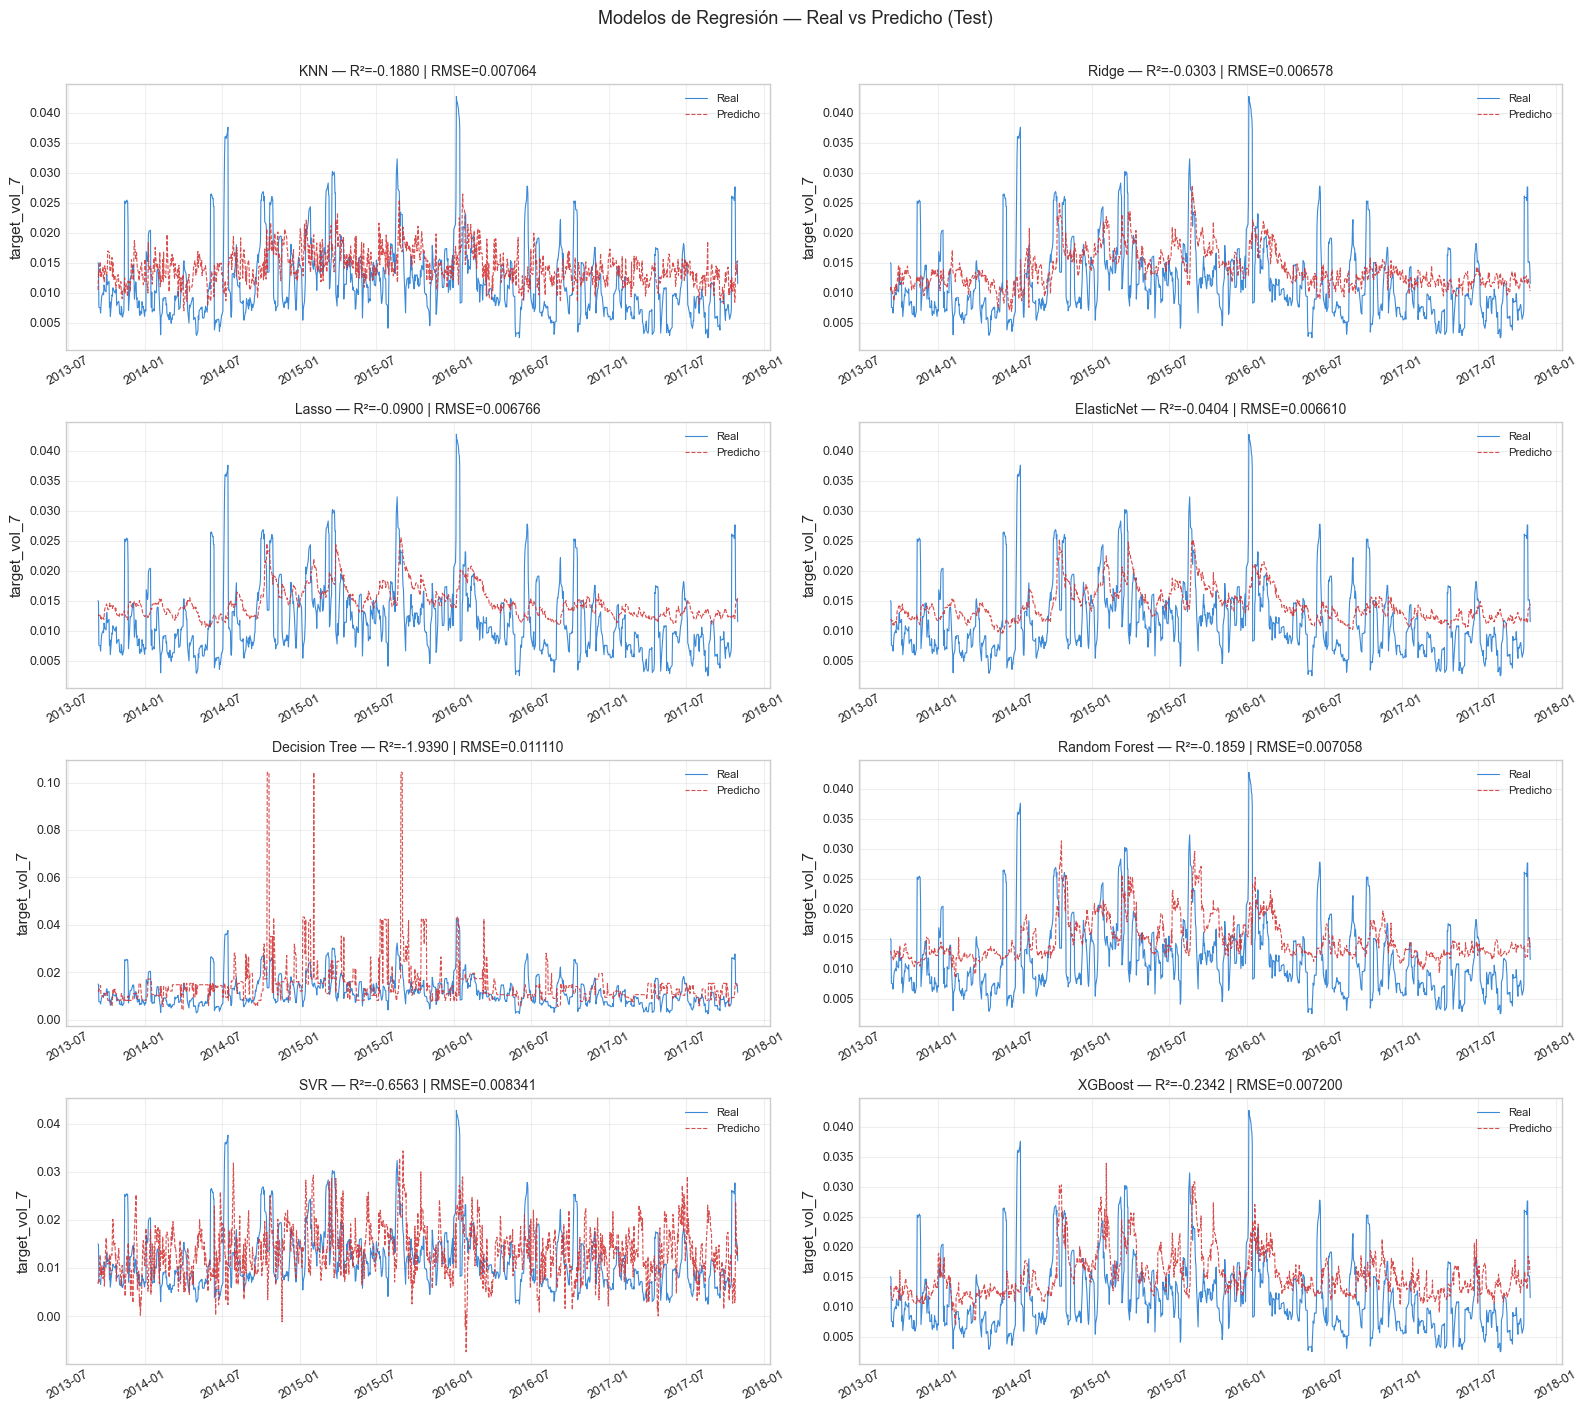

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, yp) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.plot(test["date"].values, y_test.values, color="#1976D2",
            linewidth=0.8, label="Real", alpha=0.85)
    ax.plot(test["date"].values, yp, color="#D32F2F",
            linewidth=0.8, linestyle="--", label="Predicho", alpha=0.85)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2 = r2_score(y_test, yp)
    ax.set_title(f"{name} — R²={r2:.4f} | RMSE={rmse:.6f}", fontsize=10)
    ax.set_ylabel("target_vol_7")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Modelos de Regresión — Real vs Predicho (Test)",
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** A diferencia de los benchmarks econométricos del notebook 03, los modelos de ML producen **predicciones que sí varían** en función de las features de entrada. Los modelos lineales (Ridge, Lasso, ElasticNet) tienden a predecir trayectorias suaves; los modelos basados en árboles (RF, XGBoost) producen predicciones con mayor variabilidad local pero potencial sobreajuste. La calidad relativa de los modelos se cuantifica en las tablas anteriores y se valida estadísticamente en el notebook 09.


## 7. Análisis de overfitting (R² train vs test)

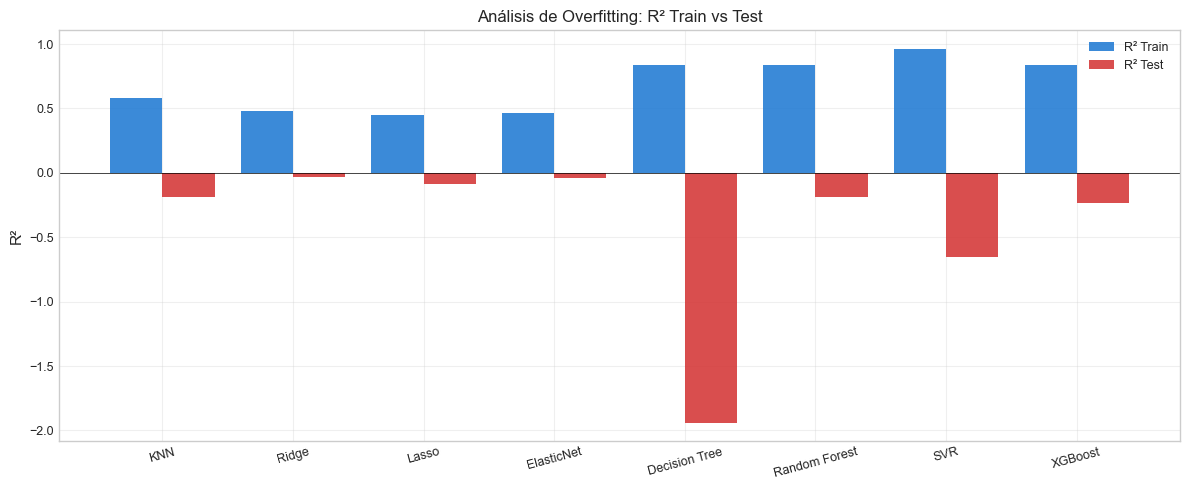

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
nombres = [r["Modelo"] for r in results_test]
r2_tr = [r["R2_train"] for r in results_test]
r2_te = [r["R2_test"] for r in results_test]
x = np.arange(len(nombres))
ax.bar(x - 0.2, r2_tr, 0.4, label="R² Train", color="#1976D2", alpha=0.85)
ax.bar(x + 0.2, r2_te, 0.4, label="R² Test", color="#D32F2F", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15)
ax.set_ylabel("R²")
ax.set_title("Análisis de Overfitting: R² Train vs Test")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** El gap entre R² de train y test indica el grado de sobreajuste. Modelos con gap pequeño (~0.05–0.10) generalizan razonablemente; gaps grandes (>0.30) indican memorización. Decision Tree y Random Forest, sin podar, son los principales candidatos a sobreajustar. Esto se mitigará en el notebook 07 con optimización formal de hiperparámetros que penalice complejidad excesiva.


## 8. Persistir predicciones, modelos y métricas

In [10]:
df_preds = pd.DataFrame({"date": test["date"].values,
                          "y_true": y_test.values})
for name, yp in predictions.items():
    df_preds[name] = yp

save_predictions_df(df_preds, "reg_test_preds")
print("✅ Predicciones persistidas en outputs/predictions/reg_test_preds.parquet")

for name, mdl in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    save_model(mdl, f"reg_{safe_name}")
print(f"✅ {len(trained_models)} modelos persistidos en outputs/models/")

metrics = {
    "cv": {r["Modelo"]: {k: r[k] for k in r if k != "Modelo"}
           for r in results_cv},
    "test": {r["Modelo"]: {k: r[k] for k in r if k != "Modelo"}
             for r in results_test},
}
save_metrics(metrics, "regression_metrics")
print("✅ Métricas en outputs/metrics/regression_metrics.json")

✅ Predicciones persistidas en outputs/predictions/reg_test_preds.parquet
✅ 8 modelos persistidos en outputs/models/
✅ Métricas en outputs/metrics/regression_metrics.json


---

## 9. Resumen del notebook

- **8 modelos de regresión** entrenados con `TimeSeriesSplit` y validados sobre test holdout.
- **Predicciones persistidas** para uso en notebooks 08 (residuos), 09 (comparación estadística) y 13 (síntesis).
- **Modelos persistidos** para uso en notebooks 07 (optimización) y 10 (interpretabilidad).
- **El mejor modelo en CV y/o test** se determina formalmente con Diebold-Mariano y bootstrap CI en el notebook 09 — los rankings de RMSE puntual aquí son indicativos pero no definitivos.

**Procede al notebook `05_clasificacion_ml.ipynb`** para los 8 modelos de clasificación.
